# CuTe Layout (hierarchical structured layout)
Layout is a function from n-d coordinate to 1-d offset, but with known output shape, the offset can also be viewed as 2D or ND. 

In [116]:
import cute_layout as cl

a1 = cl.Layout(6, 1).show(verbose=0)
a2 = cl.Layout((3, 5), (1, 3)).show("m3 n5", verbose=0)

Layout(6:1) shape(size)->coshape(cosize) 6(6)->6(6) rank:1 depth:0
     0,     1,     2,     3,     4,     5,
Layout((3, 5):(1, 3)) shape(size)->coshape(cosize) (3, 5)(15)->15(15) rank:2 depth:1
   0:     m0n0,    ..n1,    ..n2,    ..n3,    ..n4,
   1:     m1n0,    ..n1,    ..n2,    ..n3,    ..n4,
   2:     m2n0,    ..n1,    ..n2,    ..n3,    ..n4,


# Coshape & Cosize

Coshape is the minimal range or bounding box which encloses the images of layout function. it's size is called cosize, which maybe bigger-than/equal-to/smaller-than the size of layout(the size of domain):

In [117]:
a1 = cl.Layout(6, 0).show(verbose=0) # layout with cosize < size
a1 = cl.Layout(6, 1).show(verbose=0) # layout with cosize == size
a1 = cl.Layout(6, 2).show(verbose=0) # layout with cosize > size

Layout(6:0) shape(size)->coshape(cosize) 6(6)->1(1) rank:1 depth:0
     0,     0,     0,     0,     0,     0,
Layout(6:1) shape(size)->coshape(cosize) 6(6)->6(6) rank:1 depth:0
     0,     1,     2,     3,     4,     5,
Layout(6:2) shape(size)->coshape(cosize) 6(6)->11(11) rank:1 depth:0
     0,     2,     4,     6,     8,    10,


In [118]:
a2 = cl.Layout((2,3), (1,0)).show(verbose=0) # layout with cosize < size
a2 = cl.Layout((2,3), (1,2)).show(verbose=0) # layout with cosize == size
a2 = cl.Layout((2,3), (1,4)).show(verbose=0) # layout with cosize > size

Layout((2, 3):(1, 0)) shape(size)->coshape(cosize) (2, 3)(6)->2(2) rank:2 depth:1
   0:      0,     0,     0,
   1:      1,     1,     1,
Layout((2, 3):(1, 2)) shape(size)->coshape(cosize) (2, 3)(6)->6(6) rank:2 depth:1
   0:      0,     2,     4,
   1:      1,     3,     5,
Layout((2, 3):(1, 4)) shape(size)->coshape(cosize) (2, 3)(6)->10(10) rank:2 depth:1
   0:      0,     4,     8,
   1:      1,     5,     9,


# Concatenation

If we `concat(layout, s:d)`, we added another dimension into existing layout's coordinate, the coordinate instroduces new set of additional offsets `{d, 2d, 3d, ...., (s-1)d}` into the final output of layout function.

if d is small, additional offsets may produce output overlapping with exising image, for example, d=0 add an broadcast mode which contributes no offset to output.

if d is big,  additional offsets may produce gaps or wholes into the existing image.

In [119]:
a0 = cl.Layout(4, 1).show(verbose=0)
a1 = cl.concatenation(a0, cl.Layout(3, 0)).show(verbose=0)

Layout(4:1) shape(size)->coshape(cosize) 4(4)->4(4) rank:1 depth:0
     0,     1,     2,     3,
Layout((4, 3):(1, 0)) shape(size)->coshape(cosize) (4, 3)(12)->4(4) rank:2 depth:1
   0:      0,     0,     0,
   1:      1,     1,     1,
   2:      2,     2,     2,
   3:      3,     3,     3,


In [120]:
a1 = cl.concatenation(a0, cl.Layout(3, 4)).show(verbose=0)

Layout((4, 3):(1, 4)) shape(size)->coshape(cosize) (4, 3)(12)->12(12) rank:2 depth:1
   0:      0,     4,     8,
   1:      1,     5,     9,
   2:      2,     6,    10,
   3:      3,     7,    11,


In [121]:
a1 = cl.concatenation(a0, cl.Layout(3, 10)).show(verbose=0)

Layout((4, 3):(1, 10)) shape(size)->coshape(cosize) (4, 3)(12)->24(24) rank:2 depth:1
   0:      0,    10,    20,
   1:      1,    11,    21,
   2:      2,    12,    22,
   3:      3,    13,    23,


# Complement
Complement : fill the dimensional gaps (by adding the missing replications one-by-one)

complement `A∗`
R = complement(A, shapeM)

 - size(R) and cosize(R) ≤ size(M).
 - R has positive, increasing strides → unique.
 - A and R operate on disjoint mode sets. R completes the missing modes.

R fills the dimensional gaps not covered by A, following the coalescing assumption.

for example, 30=2x3x5, Possible layouts:
 - (2,3,5):(1,2,6)
 - (3,2,5):(1,3,5)
 - (2,5,3):(1,2,10)
 - ......

complement = `any split of modes into two complementary groups.`

the algorithm is based on the fact that when complement modes are concatenated with the original one,
and sorted strides in ascending order, all modes can coalesce into a single mode.
https://docs.nvidia.com/cutlass/latest/media/docs/cpp/cute/02_layout_algebra.html#complement-examples

In [122]:
cl.complement(cl.Layout(4,1), 12) == cl.Layout(3, 4) # (4:1, 3:4)
cl.complement(cl.Layout(3,4), 12) == cl.Layout(4, 1) # (3:4, 4:1)
mode0 = cl.Layout(3,4).show(verbose=0)
mode1 = cl.complement(cl.Layout(3,4), 12).show(verbose=0)

Layout(3:4) shape(size)->coshape(cosize) 3(3)->9(9) rank:1 depth:0
     0,     4,     8,
Layout(4:1) shape(size)->coshape(cosize) 4(4)->4(4) rank:1 depth:0
     0,     1,     2,     3,


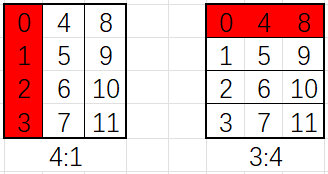

# Composition

`R=composition(A, B)` referencing elements in A by image of B, can be used to reshape/sample/transpose/...., if A is multi-dimensional, B's offset should be able to transform into meaningful coordinate in A's domain by `idx2crd()`.

Layout I is an `Identity` if `I(k) = k`, which has no effect when being composed with other :
 - `composition(A, I) = A`
 - `composition(I, A) = A`

for example, 24:1, (4,6):(1,4) are all Identity layouts.

In [123]:
a1 = cl.Layout(6, 1)
a1_view1 = cl.composition(a1, cl.Layout((2, 3),(1, 2))).show(verbose=0) # 1D view as 2D

Layout((2, 3):(1, 2)) shape(size)->coshape(cosize) (2, 3)(6)->6(6) rank:2 depth:1
   0:      0,     2,     4,
   1:      1,     3,     5,


In [124]:
a1_view1 = cl.composition(a1, cl.Layout((2, 3),(3, 1))).show(verbose=0) # 1D view as 2D transpose

Layout((2, 3):(3, 1)) shape(size)->coshape(cosize) (2, 3)(6)->6(6) rank:2 depth:1
   0:      0,     1,     2,
   1:      3,     4,     5,


In [125]:
a1_view1 = cl.composition(a1, cl.Layout((2, 3),(1, 0))).show(verbose=0) # 1D view as 2D broadcasted

Layout((2, 3):(1, 0)) shape(size)->coshape(cosize) (2, 3)(6)->2(2) rank:2 depth:1
   0:      0,     0,     0,
   1:      1,     1,     1,


In [126]:
a1_view1 = cl.composition(a1, cl.Layout(2, 5)).show(verbose=0) # 1D view as sampled 1D with different size

Layout(2:5) shape(size)->coshape(cosize) 2(2)->6(6) rank:1 depth:0
     0,     5,


In [127]:
a1_view1 = cl.composition(a1, cl.Layout((2, 2),(1, 3))).show(verbose=0) # 1D view as sampled 2D with different size

Layout((2, 2):(1, 3)) shape(size)->coshape(cosize) (2, 2)(4)->5(5) rank:2 depth:1
   0:      0,     3,
   1:      1,     4,


In [128]:
a2 = cl.Layout((6, 4), (1, 6)).show(verbose=0)
C1 = cl.composition(a2, cl.Layout((4, 6), (6, 1))).show(verbose=0) # transpose view of a2

Layout((6, 4):(1, 6)) shape(size)->coshape(cosize) (6, 4)(24)->24(24) rank:2 depth:1
   0:      0,     6,    12,    18,
   1:      1,     7,    13,    19,
   2:      2,     8,    14,    20,
   3:      3,     9,    15,    21,
   4:      4,    10,    16,    22,
   5:      5,    11,    17,    23,
Layout((4, 6):(6, 1)) shape(size)->coshape(cosize) (4, 6)(24)->24(24) rank:2 depth:1
   0:      0,     1,     2,     3,     4,     5,
   1:      6,     7,     8,     9,    10,    11,
   2:     12,    13,    14,    15,    16,    17,
   3:     18,    19,    20,    21,    22,    23,


In [129]:
C2 = cl.composition(a2, cl.Layout((2, 2), (2, 12))).show(verbose=0) # sampled as 2D

Layout((2, 2):(2, 12)) shape(size)->coshape(cosize) (2, 2)(4)->15(15) rank:2 depth:1
   0:      0,    12,
   1:      2,    14,


In [130]:
C3 = cl.coalesce(cl.composition(a2, cl.Layout(6, 2))).show(verbose=0) # sampled as 1D

Layout(6:2) shape(size)->coshape(cosize) 6(6)->11(11) rank:1 depth:0
     0,     2,     4,     6,     8,    10,


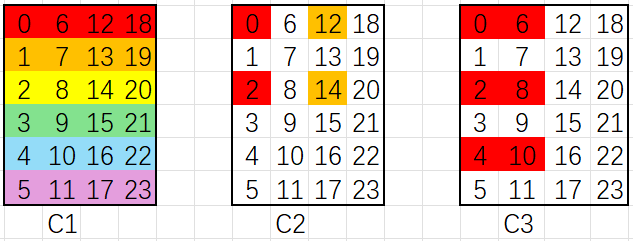

# Divide
division `A⊘B = A o (B, B∗|A|) = A o B⋆`

Given layouts A and B, their division produces a layout R such that A is split into modes:
 - mode0 : sampling elements of A by image of B  : `A o B`
 - mode1 : sampling elements of A by image B*   : `A o B*`
 - concat(mode0, mode1) : indexing elements in A in two step, `[coord_of_element_in_Btile, coord_of_Btile_in_Grid]`

|          | domain  | size |
| -------- | ------- | ----- |
| A        | (M,N,K,...)    | `size(A)` |
| B        | (m,n,....)     | `size(B)` |
| logical_divide(A, B) | ((m,n,....), (rest...)) | (`size(B)`, `size(A)/size(B)`)= `size(A)` |

so what we can see about the division result is:
 - it has two modes
 - first modes accept same coordinate for `B`, which has size of `|B|`
 - second modes accept same coordinate for `B*|A|`, which has size of `|A|/|B|`
 - mode0 is composition, so the division operation not only `divide` layout into B-tiles, but also inherit all transformations in B (so B may have finer structure to perform transpose/sub-blocking/...)

In [131]:
A = cl.Layout((4,4),(1,4))
R = cl.logical_divide(A, cl.Layout((2,2),(1,4))).show(verbose=0) # (2,2):(1,4) tile-grids (B is block view)
R = cl.logical_divide(A, cl.Layout((2,2),(2,8))).show(verbose=0) # (2,2):(2,8) tile-grids (B is scattered view)

Layout(((2, 2), (2, 2)):((1, 4), (2, 8))) shape(size)->coshape(cosize) ((2, 2), (2, 2))(16)->16(16) rank:2 depth:2
   0=(0, 0):      0,     2,     8,    10,
   1=(1, 0):      1,     3,     9,    11,
   2=(0, 1):      4,     6,    12,    14,
   3=(1, 1):      5,     7,    13,    15,
Layout(((2, 2), (2, 2)):((2, 8), (1, 4))) shape(size)->coshape(cosize) ((2, 2), (2, 2))(16)->16(16) rank:2 depth:2
   0=(0, 0):      0,     1,     4,     5,
   1=(1, 0):      2,     3,     6,     7,
   2=(0, 1):      8,     9,    12,    13,
   3=(1, 1):     10,    11,    14,    15,


Please notice that, divisor B must generate coordinates compatible with A's shape (B's codomain must lie in A's domain), that's why stride of B is (1,4) or (2,8):

 - R(:,0) accessing all yellow elements 
 - R(:,1) accessing all blue elements
 - R(:,2) accessing all red elements
 - R(:,3) accessing all white elements

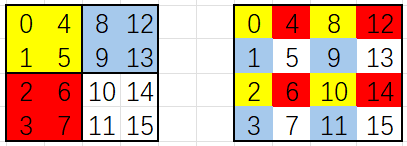

that's why such division is very counterintuitive and seldom used in practice, unless `divide(1D, 1D) => 2D` case, which is more intuitive.

In [132]:
R1 = cl.logical_divide(cl.Layout(12,1), cl.Layout(3,1)).show(verbose=0) # B is 3 adjecent elements
R2 = cl.logical_divide(cl.Layout(12,1), cl.Layout(3,2)).show(verbose=0) # B is 3 one-apart elements
R3 = cl.logical_divide(cl.Layout(12,1), cl.Layout((3,2),(2,1))).show(verbose=0) # B is 6 elements interleaved

Layout((3, 4):(1, 3)) shape(size)->coshape(cosize) (3, 4)(12)->12(12) rank:2 depth:1
   0:      0,     3,     6,     9,
   1:      1,     4,     7,    10,
   2:      2,     5,     8,    11,
Layout((3, (2, 2)):(2, (1, 6))) shape(size)->coshape(cosize) (3, (2, 2))(12)->12(12) rank:2 depth:2
   0:      0,     1,     6,     7,
   1:      2,     3,     8,     9,
   2:      4,     5,    10,    11,
Layout(((3, 2), 2):((2, 1), 6)) shape(size)->coshape(cosize) ((3, 2), 2)(12)->12(12) rank:2 depth:2
   0=(0, 0):      0,     6,
   1=(1, 0):      2,     8,
   2=(2, 0):      4,    10,
   3=(0, 1):      1,     7,
   4=(1, 1):      3,     9,
   5=(2, 1):      5,    11,


After 1D division `R = logical_divide(A, B)`, A's data is not only splited into smaller tiles of size |B|, but also notice that the ordering with the smaller tile is also changed according to B (the effect of composition).

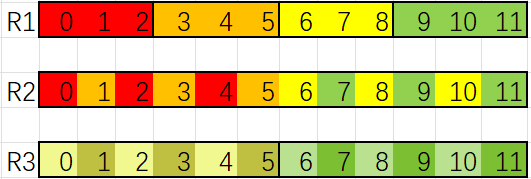

In practice, by-mode 1D divison is commonly used, Tiler is HTuple of layouts or None (to skip a mode). and most basic form of division `logical_division` will produce result with same rank as A, but the modes selected by Tiler are internally split into 2 sub-modes `(Tile, Rest)`, and zipped/tiled/flat form of division rearrange these modes based on logical_division's output in following ways:

 - Layout Shape : (M, N, L, ...)
 - Tiler Shape  : <TileM, TileN>
```
 logical_divide : ((TileM,RestM), (TileN,RestN), L, ...)
 zipped_divide  : ((TileM,TileN), (RestM,RestN,L,...))
 tiled_divide   : ((TileM,TileN), RestM, RestN, L, ...)
 flat_divide    : (TileM, TileN, RestM, RestN, L, ...)
```

In [133]:
A4 = cl.Layout((4,12),(1,4))
B4 = (None, cl.Layout((3,2),(2,1)))
R4 = cl.logical_divide(A4, B4).show("m4 n12", verbose=0) # B is 6 elements interleaved

Layout((4, ((3, 2), 2)):(1, ((8, 4), 24))) shape(size)->coshape(cosize) (4, ((3, 2), 2))(48)->48(48) rank:2 depth:3
   0:     m0n0,    ..n2,    ..n4,    ..n1,    ..n3,    ..n5,    ..n6,    ..n8,   ..n10,    ..n7,    ..n9,   ..n11,
   1:     m1n0,    ..n2,    ..n4,    ..n1,    ..n3,    ..n5,    ..n6,    ..n8,   ..n10,    ..n7,    ..n9,   ..n11,
   2:     m2n0,    ..n2,    ..n4,    ..n1,    ..n3,    ..n5,    ..n6,    ..n8,   ..n10,    ..n7,    ..n9,   ..n11,
   3:     m3n0,    ..n2,    ..n4,    ..n1,    ..n3,    ..n5,    ..n6,    ..n8,   ..n10,    ..n7,    ..n9,   ..n11,


The example above shows a very typical use of 1D by-mode division, which not only split columns of A4 into unit of 6, but also changes the iteration order of columns within this unit of 6 into (0,2,4,1,3,5), we use None to skip row-mode in the example, but we could use another 1D layout to split & reorder the rows independently too.

Note in practice, Tiler can also be hierarchical structured, and None can be used to skip some mode, and zipped result will also inherit the structure of Tiler.
```
 -     A:  (   16, (   4,    2),   6)
 - Tiler:  (    2, (   2,    1),None)
 - logical:((2,8), ((2,2),(1,2),   6)
 - zipped: ((2,(2,1)), (8,(2,2), 6))   <------ both tile-part & rest-part inherit Tiler's structure
```

# Product
product: `R = A ⊗ B = (A, A∗ o B)`

The logical product of two layouts A and B is a layout R where “each element of layout B has been replaced with a
uniquely shifted version of the layout A.”
 - mode0 is the layout A, with size `|A|`
 - mode1 is the layout A* composed with B, with size `|B|`
 - `concat(mode0, mode1)`, we got size `|A|*|B|`
 - mode0 produces orginal image/offsets of A;
 - mode1 produces `|B|`-offsets;
 - normally layout B is bijective (`size == cosize`), so it produces {`0`,`1`,`2`,...,`|B|-1`}, after composed with `A*`, it becomes {`0`,`|A|`,`2|A|`,`3|A|`,...,`(|B|-1)|A|`}

 concat 2-modes together, each element in second mode referencing “unique replication” of layout A.


|          | domain  |  size  |
| -------- | ------- | ------ | 
| A        | (M,N,K,...)    | `size(A)` |
| B        | (m,n,....)     | `size(B)` |
| product(A, B) | ((M,N,K,...), (m,n,....))  | `size(A)*size(B)` |

In [134]:
A1 = cl.Layout((2,3),(1,6)) # A1's stride is actually from R
B1 = cl.Layout((3,2),(1,3)) # B1's stride is normal
R1 = cl.logical_product(A1, B1).show(verbose=0)
A2 = cl.Layout((3,2),(1,6))
B2 = cl.Layout((2,3),(1,2))
R2 = cl.logical_product(A2, B2).show(verbose=0)
A3 = cl.Layout((3,3),(2,6))
B3 = cl.Layout((2,2),(1,2))
R3 = cl.logical_product(A3, B3).show(verbose=0)

Layout(((2, 3), (3, 2)):((1, 6), (2, 18))) shape(size)->coshape(cosize) ((2, 3), (3, 2))(36)->36(36) rank:2 depth:2
   0=(0, 0):      0,     2,     4,    18,    20,    22,
   1=(1, 0):      1,     3,     5,    19,    21,    23,
   2=(0, 1):      6,     8,    10,    24,    26,    28,
   3=(1, 1):      7,     9,    11,    25,    27,    29,
   4=(0, 2):     12,    14,    16,    30,    32,    34,
   5=(1, 2):     13,    15,    17,    31,    33,    35,
Layout(((3, 2), (2, 3)):((1, 6), (3, 12))) shape(size)->coshape(cosize) ((3, 2), (2, 3))(36)->36(36) rank:2 depth:2
   0=(0, 0):      0,     3,    12,    15,    24,    27,
   1=(1, 0):      1,     4,    13,    16,    25,    28,
   2=(2, 0):      2,     5,    14,    17,    26,    29,
   3=(0, 1):      6,     9,    18,    21,    30,    33,
   4=(1, 1):      7,    10,    19,    22,    31,    34,
   5=(2, 1):      8,    11,    20,    23,    32,    35,
Layout(((3, 3), (2, 2)):((2, 6), (1, 18))) shape(size)->coshape(cosize) ((3, 3), (2, 2))(36)->36

Notice that, similar to divide, A's codomain must lie in R's codomain. but B can be specified independently.

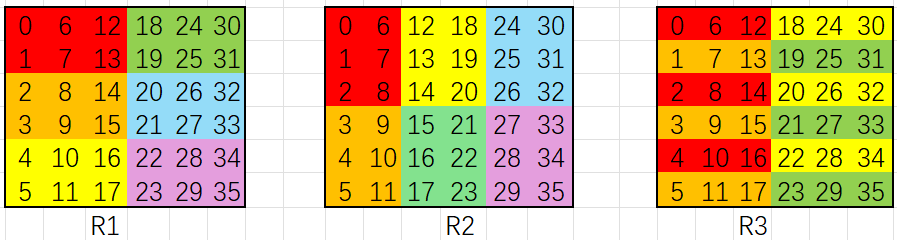

So product of N-D layout is also counterintuitive, the most commonly used product is 1D

In [135]:
R1 = cl.logical_product(cl.Layout(3,1), cl.Layout(2,1)).show(verbose=0)
R2 = cl.logical_product(cl.Layout(3,1), cl.Layout((2,2),(2,1))).show(verbose=0)

Layout((3, 2):(1, 3)) shape(size)->coshape(cosize) (3, 2)(6)->6(6) rank:2 depth:1
   0:      0,     3,
   1:      1,     4,
   2:      2,     5,
Layout((3, (2, 2)):(1, (6, 3))) shape(size)->coshape(cosize) (3, (2, 2))(12)->12(12) rank:2 depth:2
   0:      0,     6,     3,     9,
   1:      1,     7,     4,    10,
   2:      2,     8,     5,    11,



 - Layout Shape : (M, N, L, ...)
 - Tiler Shape  : <TileM, TileN>

```
logical_product : ((M,TileM), (N,TileN), L, ...)
zipped_product  : ((M,N), (TileM,TileN,L,...))
tiled_product   : ((M,N), TileM, TileN, L, ...)
flat_product    : (M, N, TileM, TileN, L, ...)
```